In [27]:
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
import numpy as np

In [28]:
def teleportation_register():
    """
    Initializes quantum and classical registers for the teleportation protocol.
    Returns:
        qc: QuantumCircuit object
        q_state: Register holding the state to be teleported
        alice: Alice's half of the Bell pair
        bob: Bob's half of the Bell pair
        cr: Classical register for measurement results
    """
    qubit = QuantumRegister(1, "Q")
    Alice = QuantumRegister(1, "A")
    Bob = QuantumRegister(1, "B")

    cr = ClassicalRegister(3, "c")

    qc = QuantumCircuit(qubit, Alice, Bob, cr)
    return qc, qubit, Alice, Bob, cr

In [29]:
def create_entanglement(qc, Alice, Bob):
    """
    Creates a shared Bell pair (entangled state) between Alice and Bob.
    """
    qc.h(Alice)
    qc.cx(Alice, Bob)

    qc.barrier()

    return qc

In [30]:
def prepare_random_state(qc, qubit):
    """
    Prepares an arbitrary quantum state on the Bloch sphere using a U-gate.
    """
    np.random.seed(42)
    theta = np.random.uniform(0.0, 0.1)
    varphi = np.random.uniform(0.0, 0.2)
    qc.u(theta, varphi, 0.0, qubit)

    qc.barrier()
    
    return qc, theta, varphi

In [31]:
def teleportation_protocol(qc, qubit, Alice):
    """
    Alice performs operations on her qubits to encode the state information.
    """
    qc.cx(qubit, Alice)
    qc.h(qubit)

    qc.barrier()
    return qc

In [32]:
def bob_correction(qc, Alice, qubit, Bob, cr):
    """
    Measures Alice's qubits and applies conditional corrections to Bob's qubit.
    """
    qc.measure(Alice, cr[1])
    qc.measure(qubit, cr[0])

    with qc.if_test((cr[1], 1)):
        qc.x(Bob)
    with qc.if_test((cr[0], 1)):
        qc.z(Bob)
    
    return qc

In [ ]:
def run_teleportation():
    qc, qubit, Alice, Bob, cr = teleportation_register()
    create_entanglement(qc, Alice, Bob)
    qc, theta, varphi = prepare_random_state(qc, qubit)
    teleportation_protocol(qc, qubit, Alice)
    bob_correction(qc, Alice, qubit, Bob, cr)
    
    return qc, theta, varphi, Bob, cr

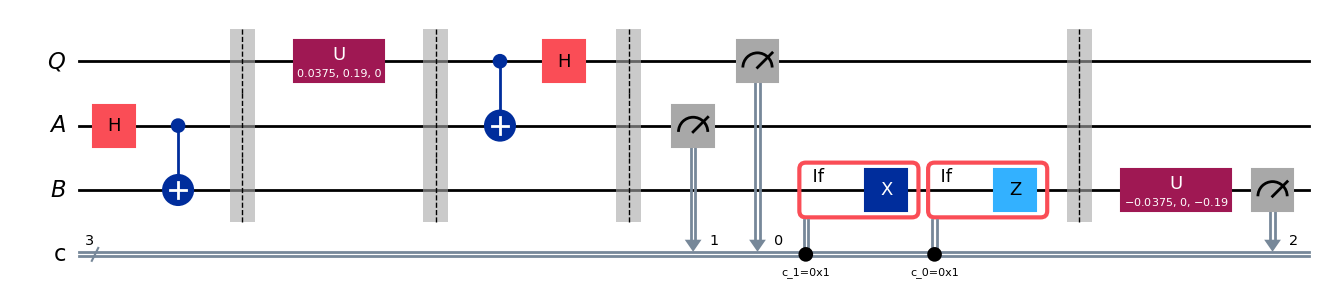

In [34]:
# measure Bob's qubit
qc, theta, varphi, bob, cr = run_teleportation()
qc.barrier()
qc.u(theta, varphi, 0.0, bob).inverse()
qc.measure(bob, cr[2])

qc.draw(output="mpl")

In [ ]:
#state checking

from qiskit_aer import AerSimulator

shots = 1024
simulator = AerSimulator()

qc, theta, varphi, bob, cr = run_teleportation()
qc.barrier()
qc.u(theta, varphi, 0.0, bob).inverse()
qc.measure(bob, cr[2])

result = simulator.run(qc, shots=shots).result()
counts = result.get_counts(qc)

bob_0 = sum(v for k, v in counts.items() if k[0] == "0")
p_bob_0 = bob_0 / shots

print(f"P(Bob=0) po U† = {p_bob_0:.6f}")

P(Bob=0) po U† = 1.000000


In [37]:
# Add noise

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError

def make_noise_model(p_1q, p_2q, p_readout):
    noise_model = NoiseModel()

    err_1q = depolarizing_error(p_1q, 1)
    err_2q = depolarizing_error(p_2q, 2)

    for gate in ["x", "h", "z"]:
        noise_model.add_all_qubit_quantum_error(err_1q, gate)
    noise_model.add_all_qubit_quantum_error(err_2q, "cx")

    read_error = ReadoutError([[1 - p_readout, p_readout], [p_readout, 1 - p_readout]])
    noise_model.add_all_qubit_readout_error(read_error)

    return noise_model

In [39]:
# Run simulation

from qiskit import transpile

shots = 1024

ideal_backend = AerSimulator()
noise_backend = AerSimulator(noise_model=make_noise_model(0.01, 0.02, 0.05))

circuit, theta, varphi, Bob, cr = run_teleportation()

compiled_ideal_backend = transpile(circuit, ideal_backend)
compiled_noise_backend = transpile(circuit, noise_backend)

ideal_job = ideal_backend.run(compiled_ideal_backend, shots=shots)
noise_job = noise_backend.run(compiled_noise_backend, shots=shots)

ideal_counts = ideal_job.result().get_counts()
noise_counts = noise_job.result().get_counts()

print("Ideal counts:", ideal_counts)
print("Noisy counts:", noise_counts)

Ideal counts: {'001': 244, '011': 262, '010': 260, '000': 258}
Noisy counts: {'001': 264, '000': 235, '011': 262, '010': 263}
